# Aggregate the OGGM v1.6.3 rgiv62 raw files to regional or global summed up csv files


*Note that the paths of this notebook only work if you are running the notebook from the OGGM cluster*


In [1]:
import xarray as xr
import pandas as pd
import progressbar
import numpy as np
from oggm.utils import mkdir
import matplotlib.pyplot as plt
import json
import os
import glob

In [2]:
%pwd

'/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/1.6.3'

In [3]:
dirpath = '/home/www/oggm/oggm-standard-projections/oggm_v16/2025.6/'
outputpath = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3'
# for OGGM v1.6.3, we only ran `w5e5_gcm_merged` 
# (i.e., w5e5 until end of 2019, and the climate models from thereon)
historical_future_option = 'w5e5_gcm_merged'

# this is the only preprocessed version (i.e., we match the geodetic observations on any individual glacier)
baseline_climate = 'w5e5'
exp = 'per_glacier_spinup'  # this is actually the same as "match_geod_pergla" (if the dynamic spinup gdirs are used)
## new for OGGM v1.6.3 --> additional experiments
dirpath = dirpath + f'{baseline_climate}/{exp}/'
outputpath = outputpath + f'/{baseline_climate}/{exp}'

oggm_version = 'oggm_v1.6.3_2025.6'

rgi_meta = pd.read_hdf('/home/www/oggm/rgi/rgi62_stats.h5')
rgi_meta = rgi_meta.loc[rgi_meta.Connect != 2]

## A. Common running glacier aggregations for all projections, until 2100 and until 2300, i.e. `common_running_2100_2300`
- the same for only until 2100 is done in Section B further below

### A. 1: GCMs - missing glaciers overview  

In [4]:
mkdir(outputpath + '/common_running_2100')
mkdir(outputpath + '/common_running_2100_2300')


'/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3/w5e5/per_glacier_spinup/common_running_2100_2300'

In [5]:
allfiles = []
for root, dirs, files in os.walk(dirpath):
    for file in files:
        if (file.endswith(".nc")) and ('run_hydro' in file) and (historical_future_option in file) and ('_0_1000' in file) and ('basin' not in file):
             allfiles.append(os.path.join(root, file))

df_meta = pd.DataFrame()
invalid_per_reg = {}  
meta_per_reg = {}

In [ ]:
run = True
if run:
    # this takes very long !!!
    invalid_per_reg = {}  
    meta_per_reg = {}
    for f in allfiles: #progressbar.progressbar(allfiles):
        ename = f.replace(dirpath, '')
        ss = ename.split('/')
        cmip = ss[0]
        endyr = ss[1]
        rgi_reg = ss[2]
        gcm_original = ss[3].split('_')[5] #ss[2]
        gcm = gcm_original.upper()
        if 'ISIMIP3b' in cmip:
            ssp = ss[3].split('_')[7]
            bc = 'ISIMIP3b:1979-2014'
        else:
            ssp = ss[3].split('_')[6]
            bc = '2000-2019'

        end0,end1 = ss[3].split('_')[-2:]
        end = end0+'_'+end1
        ff = f[:-len(end)]+'*'

        #if ssp not in ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']:
        #    continue

        # exp is the same everywhere, so we don't need as an id... 
        run_id = f'{cmip}:{endyr}:{gcm}:{ssp}:{rgi_reg}'
        df_meta.loc[run_id, 'cmip'] = cmip
        df_meta.loc[run_id, 'gcm_original'] = gcm_original # some have lower and upper cases in the raw output files
        df_meta.loc[run_id, 'gcm'] = gcm  # for the aggregated files, all GCMs are in upper cases
        df_meta.loc[run_id, 'scenario'] = ssp
        df_meta.loc[run_id, 'rgi_reg'] = rgi_reg
        df_meta.loc[run_id, 'end_year'] = ''  # changed from 0 to this, to remove warning
        df_meta.loc[run_id, 'bias_correction'] = bc

        df_meta.loc[run_id, 'perc_area_missing'] = 0

        df_meta.loc[run_id, 'fpath'] = ff

        if rgi_reg not in invalid_per_reg:
            invalid_per_reg[rgi_reg] = set()

        if rgi_reg not in meta_per_reg:
            meta_per_reg[rgi_reg] = rgi_meta.loc[rgi_meta['O1Region'] == rgi_reg[-2:]]

        with xr.open_mfdataset(ff) as ds:
            ds_t = ds.isel(time=-1).volume.load()
        df_meta.loc[run_id, 'end_year'] = str(int(ds_t.time))
        missing_ids = ds_t.rgi_id[ds_t.isnull()].data
        perc = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum() / meta_per_reg[rgi_reg]['Area'].sum() 
        df_meta.loc[run_id, 'perc_area_missing'] = perc
        invalid_per_reg[rgi_reg] = invalid_per_reg[rgi_reg].union(missing_ids)
        if f == allfiles[1000] or f==allfiles[2000]:
            print(f)
    df_meta['exp'] = exp
    df_meta['historical_future_option'] = historical_future_option
    df_meta['oggm_version'] = oggm_version
    df_meta.to_csv(f'{outputpath}/common_running_2100_2300/metadata.csv')
else:
    df_meta = pd.read_csv(f'{outputpath}/common_running_2100_2300/metadata.csv')

In [ ]:
df_meta.cmip.unique()

In [ ]:
dds = df_meta.sort_values('perc_area_missing', ascending=False)
dds[dds['perc_area_missing'] > 0.05].rgi_reg.unique()

In [ ]:
dds

In [ ]:
for k, v in invalid_per_reg.items():
    invalid_per_reg[k] = list(v)
with open(f'{outputpath}/common_running_2100_2300/rgi_ids_missing.json', 'w') as f:
    json.dump(invalid_per_reg, f)

In [ ]:
# these are now the common running glaciers over all scenarios and GCMs and all cmip variants going until 2100 or until 2300
odf = pd.DataFrame()
for rgi_reg, missing_ids in invalid_per_reg.items():
    odf.loc[rgi_reg, 'n_glaciers'] = len(meta_per_reg[rgi_reg])
    odf.loc[rgi_reg, 'n_missing_glaciers'] = len(missing_ids)
    odf.loc[rgi_reg, 'rgi_area_km2'] = meta_per_reg[rgi_reg]['Area'].sum() 
    odf.loc[rgi_reg, 'missing_area_km2'] = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum()
    odf.loc[rgi_reg, 'missing_area_perc'] = odf.loc[rgi_reg, 'missing_area_km2'] / odf.loc[rgi_reg, 'rgi_area_km2']
odf[['n_glaciers', 'n_missing_glaciers']] = odf[['n_glaciers', 'n_missing_glaciers']].astype(int)
odf = odf.sort_values(by='missing_area_perc', ascending=False)
odf

In [ ]:
odf.to_csv(f'{outputpath}/common_running_2100_2300/missing_region_overview.csv')
odf.to_html(f'{outputpath}/common_running_2100_2300/missing_region_overview.html')

In [15]:
odf

,n_glaciers,n_missing_glaciers,rgi_area_km2,missing_area_km2,missing_area_perc
RGI12,1888,467,1306.992,170.445,0.130410
RGI06,568,443,11059.700,995.823,0.090041
RGI08,3417,1163,2949.103,246.684,0.083647
RGI17,15908,145,29429.080,1292.437,0.043917
RGI10,5151,254,2410.051,93.643,0.038855
RGI05,19306,1656,89717.066,1558.197,0.017368
RGI13,54429,1721,49303.415,704.778,0.014295
RGI15,13119,80,14734.204,161.690,0.010974
RGI07,1615,52,33958.934,238.612,0.007026
RGI03,4556,202,105110.642,621.852,0.005916


### A. 2: GCMs - aggregation

In [18]:
base_dir =f'{outputpath}/common_running_2100_2300'
df_meta = pd.read_csv(f'{base_dir}/metadata.csv', index_col = 0)
# for the csv files, we aggregate them only until beginning of 2100
# to have something consistent, although some GCMs are run until end of 2100
df_meta.loc[df_meta.end_year==2101, 'end_year'] = 2100
df_meta.loc[df_meta.end_year==2301, 'end_year'] = 2300
import json
with open(f'{base_dir}/rgi_ids_missing.json', 'r') as f:
    invalid_per_reg = json.load(f)

In [ ]:
for cmip in df_meta.cmip.unique():
    if cmip == 'CMIP6' or cmip == 'CMIP5':
        end_years = [2100, 2300]
    else:
        end_years = [2100]
    for end_year in end_years:
        for rgi_reg in sorted(df_meta.rgi_reg.unique()): 
            for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                df_meta_s = df_meta.loc[(df_meta.end_year == end_year) & (df_meta.cmip == cmip) & (df_meta.rgi_reg == rgi_reg) & (df_meta.scenario == scenario)]
                odf_v = pd.DataFrame()
                odf_a = pd.DataFrame()
                ods = []
                gcms = []
                for i, s in df_meta_s.iterrows():
                    with xr.open_mfdataset(s.fpath) as ds:
                        # make sure that we only aggregate if all batch files are available
                        # could happen that one has not finished ... or did not run...
                        n_files = len(glob.glob(s.fpath))
                        assert np.ceil(len(rgi_meta.loc[rgi_meta.O1Region==rgi_reg[-2:]])/1000) == n_files
                        # not look until year 2101
                        ds = ds.sel(time=slice(2000,end_year))
                        ds = ds[['volume', 'area']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        odf_v[s.gcm] = ds.volume.sum(dim='rgi_id').to_series()
                        odf_a[s.gcm] = ds.area.sum(dim='rgi_id').to_series()
                        ods.append(ds)
                        gcms.append(s.gcm)
                ods = xr.concat(ods, 'gcm')

                odir =  f'{base_dir}/volume/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_v.to_csv(odir + f'{scenario}.csv')
                odir = f'{base_dir}/area/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_a.to_csv(odir + f'{scenario}.csv')

In [ ]:
# globally: sum over all RGI regions
for var in ['volume', 'area']:
    for cmip in df_meta.cmip.unique():
        if cmip == 'CMIP6' or cmip == 'CMIP5':
            end_years = [2100, 2300]
        else:
            end_years = [2100]
        for end_year in end_years:
            odir = f'{base_dir}/{var}/{cmip}/{end_year}/global/'
            mkdir(odir)
            for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                odf = 0
                for rgi_reg in sorted(df_meta.rgi_reg.unique()):
                    idir = f'{base_dir}/{var}/{cmip}/{end_year}/{rgi_reg}/'
                    df = pd.read_csv(idir + f'/{scenario}.csv', index_col=0)
                    odf += df
                odf.to_csv(odir + f'/{scenario}.csv')
                

## B. Common running glacier aggregations for all projections until 2100, i.e. `common_running_2100`

### B. 1: GCMs - missing glaciers overview  

In [22]:
allfiles = []
for root, dirs, files in os.walk(dirpath):
    if not '/2300/' in root:
        for file in files:
            if (file.endswith(".nc")) and ('run_hydro' in file) and (historical_future_option in file) and ('_0_1000' in file) and ('basin' not in file):
                 allfiles.append(os.path.join(root, file))

df_meta = pd.DataFrame()
invalid_per_reg = {}  
meta_per_reg = {}

In [23]:
print(len(allfiles))

3325


In [24]:
# this takes very long !!!
invalid_per_reg = {}  
meta_per_reg = {}
for f in allfiles: #progressbar.progressbar(allfiles):
    ename = f.replace(dirpath, '')
    ss = ename.split('/')
    cmip = ss[0]
    endyr = ss[1]
    rgi_reg = ss[2]
    gcm_original = ss[3].split('_')[5] 
    gcm = gcm_original.upper()
    if 'ISIMIP3b' in cmip:
        ssp = ss[3].split('_')[7]
        bc = 'ISIMIP3b:1979-2014'
    else:
        ssp = ss[3].split('_')[6]
        bc = '2000-2019'

    end0,end1 = ss[3].split('_')[-2:]
    end = end0+'_'+end1
    ff = f[:-len(end)]+'*'

    # exp is the same everywhere, so we don't need it as an id... 
    run_id = f'{cmip}:{endyr}:{gcm}:{ssp}:{rgi_reg}'
    df_meta.loc[run_id, 'cmip'] = cmip
    df_meta.loc[run_id, 'gcm_original'] = gcm_original # some have lower and upper cases in the raw output files
    df_meta.loc[run_id, 'gcm'] = gcm  # for the aggregated files, all GCMs are in upper cases
    df_meta.loc[run_id, 'scenario'] = ssp
    df_meta.loc[run_id, 'rgi_reg'] = rgi_reg
    df_meta.loc[run_id, 'end_year'] = 'nan'  # changed from 0 to this, to remove warning
    df_meta.loc[run_id, 'bias_correction'] = bc
    df_meta.loc[run_id, 'perc_area_missing'] = 0
    df_meta.loc[run_id, 'fpath'] = ff
    
    if rgi_reg not in invalid_per_reg:
        invalid_per_reg[rgi_reg] = set()
    
    if rgi_reg not in meta_per_reg:
        meta_per_reg[rgi_reg] = rgi_meta.loc[rgi_meta['O1Region'] == rgi_reg[-2:]]
    
    with xr.open_mfdataset(ff) as ds:
        ds_t = ds.isel(time=-1).volume.load()
    df_meta.loc[run_id, 'end_year'] = str(int(ds_t.time))
    missing_ids = ds_t.rgi_id[ds_t.isnull()].data
    perc = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum() / meta_per_reg[rgi_reg]['Area'].sum() 
    df_meta.loc[run_id, 'perc_area_missing'] = perc
    invalid_per_reg[rgi_reg] = invalid_per_reg[rgi_reg].union(missing_ids)
    if f == allfiles[100]:
        print(f)
df_meta['exp'] = exp
df_meta['historical_future_option'] = historical_future_option
df_meta['oggm_version'] = oggm_version
df_meta.to_csv(f'{outputpath}/common_running_2100/metadata.csv')

/home/www/oggm/oggm-standard-projections/oggm_v16/2025.6/w5e5/per_glacier_spinup/CMIP5/2100/RGI11/run_hydro_w5e5_gcm_merged_CESM1-CAM5_rcp45_bc_2000_2019_endyr2101_Batch_0_1000.nc


In [25]:
dds = df_meta.sort_values('perc_area_missing', ascending=False)
dds[dds['perc_area_missing'] > 0.05].rgi_reg.unique()

array(['RGI12'], dtype=object)

In [26]:
dds

,cmip,gcm_original,gcm,scenario,rgi_reg,end_year,bias_correction,perc_area_missing,fpath,exp,historical_future_option,oggm_version
CMIP5:2100:CANESM2:rcp26:RGI12,CMIP5,CanESM2,CANESM2,rcp26,RGI12,2101,2000-2019,0.121212,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP6:2100:NORESM2-MM:ssp126:RGI12,CMIP6,NorESM2-MM,NORESM2-MM,ssp126,RGI12,2101,2000-2019,0.120878,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:IPSL-CM5A-LR:rcp26:RGI12,CMIP5,IPSL-CM5A-LR,IPSL-CM5A-LR,rcp26,RGI12,2101,2000-2019,0.119621,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:MPI-ESM-LR:rcp26:RGI12,CMIP5,MPI-ESM-LR,MPI-ESM-LR,rcp26,RGI12,2101,2000-2019,0.119372,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:CANESM2:rcp45:RGI12,CMIP5,CanESM2,CANESM2,rcp45,RGI12,2101,2000-2019,0.119332,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
...,...,...,...,...,...,...,...,...,...,...,...,...
CMIP5:2100:NORESM1-M:rcp26:RGI07,CMIP5,NorESM1-M,NORESM1-M,rcp26,RGI07,2101,2000-2019,0.000002,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:CESM1-CAM5:rcp26:RGI07,CMIP5,CESM1-CAM5,CESM1-CAM5,rcp26,RGI07,2101,2000-2019,0.000002,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:CCSM4:rcp26:RGI07,CMIP5,CCSM4,CCSM4,rcp26,RGI07,2101,2000-2019,0.000002,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6
CMIP5:2100:GISS-E2-R:rcp45:RGI07,CMIP5,GISS-E2-R,GISS-E2-R,rcp45,RGI07,2101,2000-2019,0.000002,/home/www/oggm/oggm-standard-projections/oggm_...,per_glacier_spinup,w5e5_gcm_merged,oggm_v1.6.3_2025.6


In [27]:
for k, v in invalid_per_reg.items():
    invalid_per_reg[k] = list(v)
with open(f'{outputpath}/common_running_2100/rgi_ids_missing.json', 'w') as f:
    json.dump(invalid_per_reg, f)

# these are now the common running glaciers over all scenarios and GCMs and all cmip variants going until 2100 or until 2300
odf = pd.DataFrame()
for rgi_reg, missing_ids in invalid_per_reg.items():
    odf.loc[rgi_reg, 'n_glaciers'] = len(meta_per_reg[rgi_reg])
    odf.loc[rgi_reg, 'n_missing_glaciers'] = len(missing_ids)
    odf.loc[rgi_reg, 'rgi_area_km2'] = meta_per_reg[rgi_reg]['Area'].sum() 
    odf.loc[rgi_reg, 'missing_area_km2'] = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum()
    odf.loc[rgi_reg, 'missing_area_perc'] = odf.loc[rgi_reg, 'missing_area_km2'] / odf.loc[rgi_reg, 'rgi_area_km2']
odf[['n_glaciers', 'n_missing_glaciers']] = odf[['n_glaciers', 'n_missing_glaciers']].astype(int)
odf = odf.sort_values(by='missing_area_perc', ascending=False)
odf

,n_glaciers,n_missing_glaciers,rgi_area_km2,missing_area_km2,missing_area_perc
RGI12,1888,406,1306.992,160.655,0.122920
RGI10,5151,173,2410.051,88.202,0.036598
RGI06,568,137,11059.700,302.518,0.027353
RGI03,4556,158,105110.642,595.396,0.005664
RGI02,18855,614,14524.224,30.103,0.002073
RGI19,2752,574,132867.219,272.313,0.002050
RGI13,54429,356,49303.415,93.986,0.001906
RGI17,15908,95,29429.080,46.465,0.001579
RGI05,19306,355,89717.066,92.762,0.001034
RGI15,13119,36,14734.204,12.558,0.000852


In [28]:
odf.to_csv(f'{outputpath}/common_running_2100/missing_region_overview.csv')
odf.to_html(f'{outputpath}/common_running_2100/missing_region_overview.html')

In [29]:
odf

,n_glaciers,n_missing_glaciers,rgi_area_km2,missing_area_km2,missing_area_perc
RGI12,1888,406,1306.992,160.655,0.122920
RGI10,5151,173,2410.051,88.202,0.036598
RGI06,568,137,11059.700,302.518,0.027353
RGI03,4556,158,105110.642,595.396,0.005664
RGI02,18855,614,14524.224,30.103,0.002073
RGI19,2752,574,132867.219,272.313,0.002050
RGI13,54429,356,49303.415,93.986,0.001906
RGI17,15908,95,29429.080,46.465,0.001579
RGI05,19306,355,89717.066,92.762,0.001034
RGI15,13119,36,14734.204,12.558,0.000852


### B. 2: GCMs - aggregation

In [30]:
base_dir =f'{outputpath}/common_running_2100'
df_meta = pd.read_csv(f'{base_dir}/metadata.csv', index_col = 0)
# for the csv files, we aggregate them only until beginning of 2100
# to have something consistent, although some GCMs are run until end of 2100
df_meta.loc[df_meta.end_year==2101, 'end_year'] = 2100
with open(f'{base_dir}/rgi_ids_missing.json', 'r') as f:
    invalid_per_reg = json.load(f)

In [31]:
for cmip in df_meta.cmip.unique():
    print(cmip, flush=True)
    if cmip == 'CMIP6':
        end_years = [2100]
    else:
        end_years = [2100]
    for end_year in end_years:
        for rgi_reg in sorted(df_meta.rgi_reg.unique()): #progressbar.progressbar(
            for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                df_meta_s = df_meta.loc[(df_meta.end_year == end_year) & (df_meta.cmip == cmip) & (df_meta.rgi_reg == rgi_reg) & (df_meta.scenario == scenario)]
                odf_v = pd.DataFrame()
                odf_a = pd.DataFrame()
                ods = []
                gcms = []
                for i, s in df_meta_s.iterrows():
                    with xr.open_mfdataset(s.fpath) as ds:
                        # make sure that we only aggregate if all batch files are available
                        # could happen that one has not finished ... or did not run...
                        n_files = len(glob.glob(s.fpath))
                        assert np.ceil(len(rgi_meta.loc[rgi_meta.O1Region==rgi_reg[-2:]])/1000) == n_files
                        # not look until year 2101
                        ds = ds.sel(time=slice(2000,end_year))
                        ds = ds[['volume', 'area']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        #ds = ds[['volume', 'area', 'length']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                        odf_v[s.gcm] = ds.volume.sum(dim='rgi_id').to_series()
                        odf_a[s.gcm] = ds.area.sum(dim='rgi_id').to_series()
                        ods.append(ds)
                        gcms.append(s.gcm)
                ods = xr.concat(ods, 'gcm')
                odir =  f'{base_dir}/volume/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_v.to_csv(odir + f'{scenario}.csv')
                odir = f'{base_dir}/area/{cmip}/{end_year}/{rgi_reg}/'
                mkdir(odir)
                odf_a.to_csv(odir + f'{scenario}.csv')

CMIP5
ISIMIP3b_CMIP6
CMIP6


In [32]:
# globally: sum over all RGI regions
for var in ['volume', 'area']:
    for cmip in df_meta.cmip.unique():
        odir = f'{base_dir}/{var}/{cmip}/{end_year}/global/'
        mkdir(odir)
        for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
            odf = 0
            for rgi_reg in sorted(df_meta.rgi_reg.unique()):
                idir = f'{base_dir}/{var}/{cmip}/{end_year}/{rgi_reg}/'
                df = pd.read_csv(idir + f'/{scenario}.csv', index_col=0)
                odf += df
            odf.to_csv(odir + f'/{scenario}.csv')

# Visualisation of missing common running glaciers

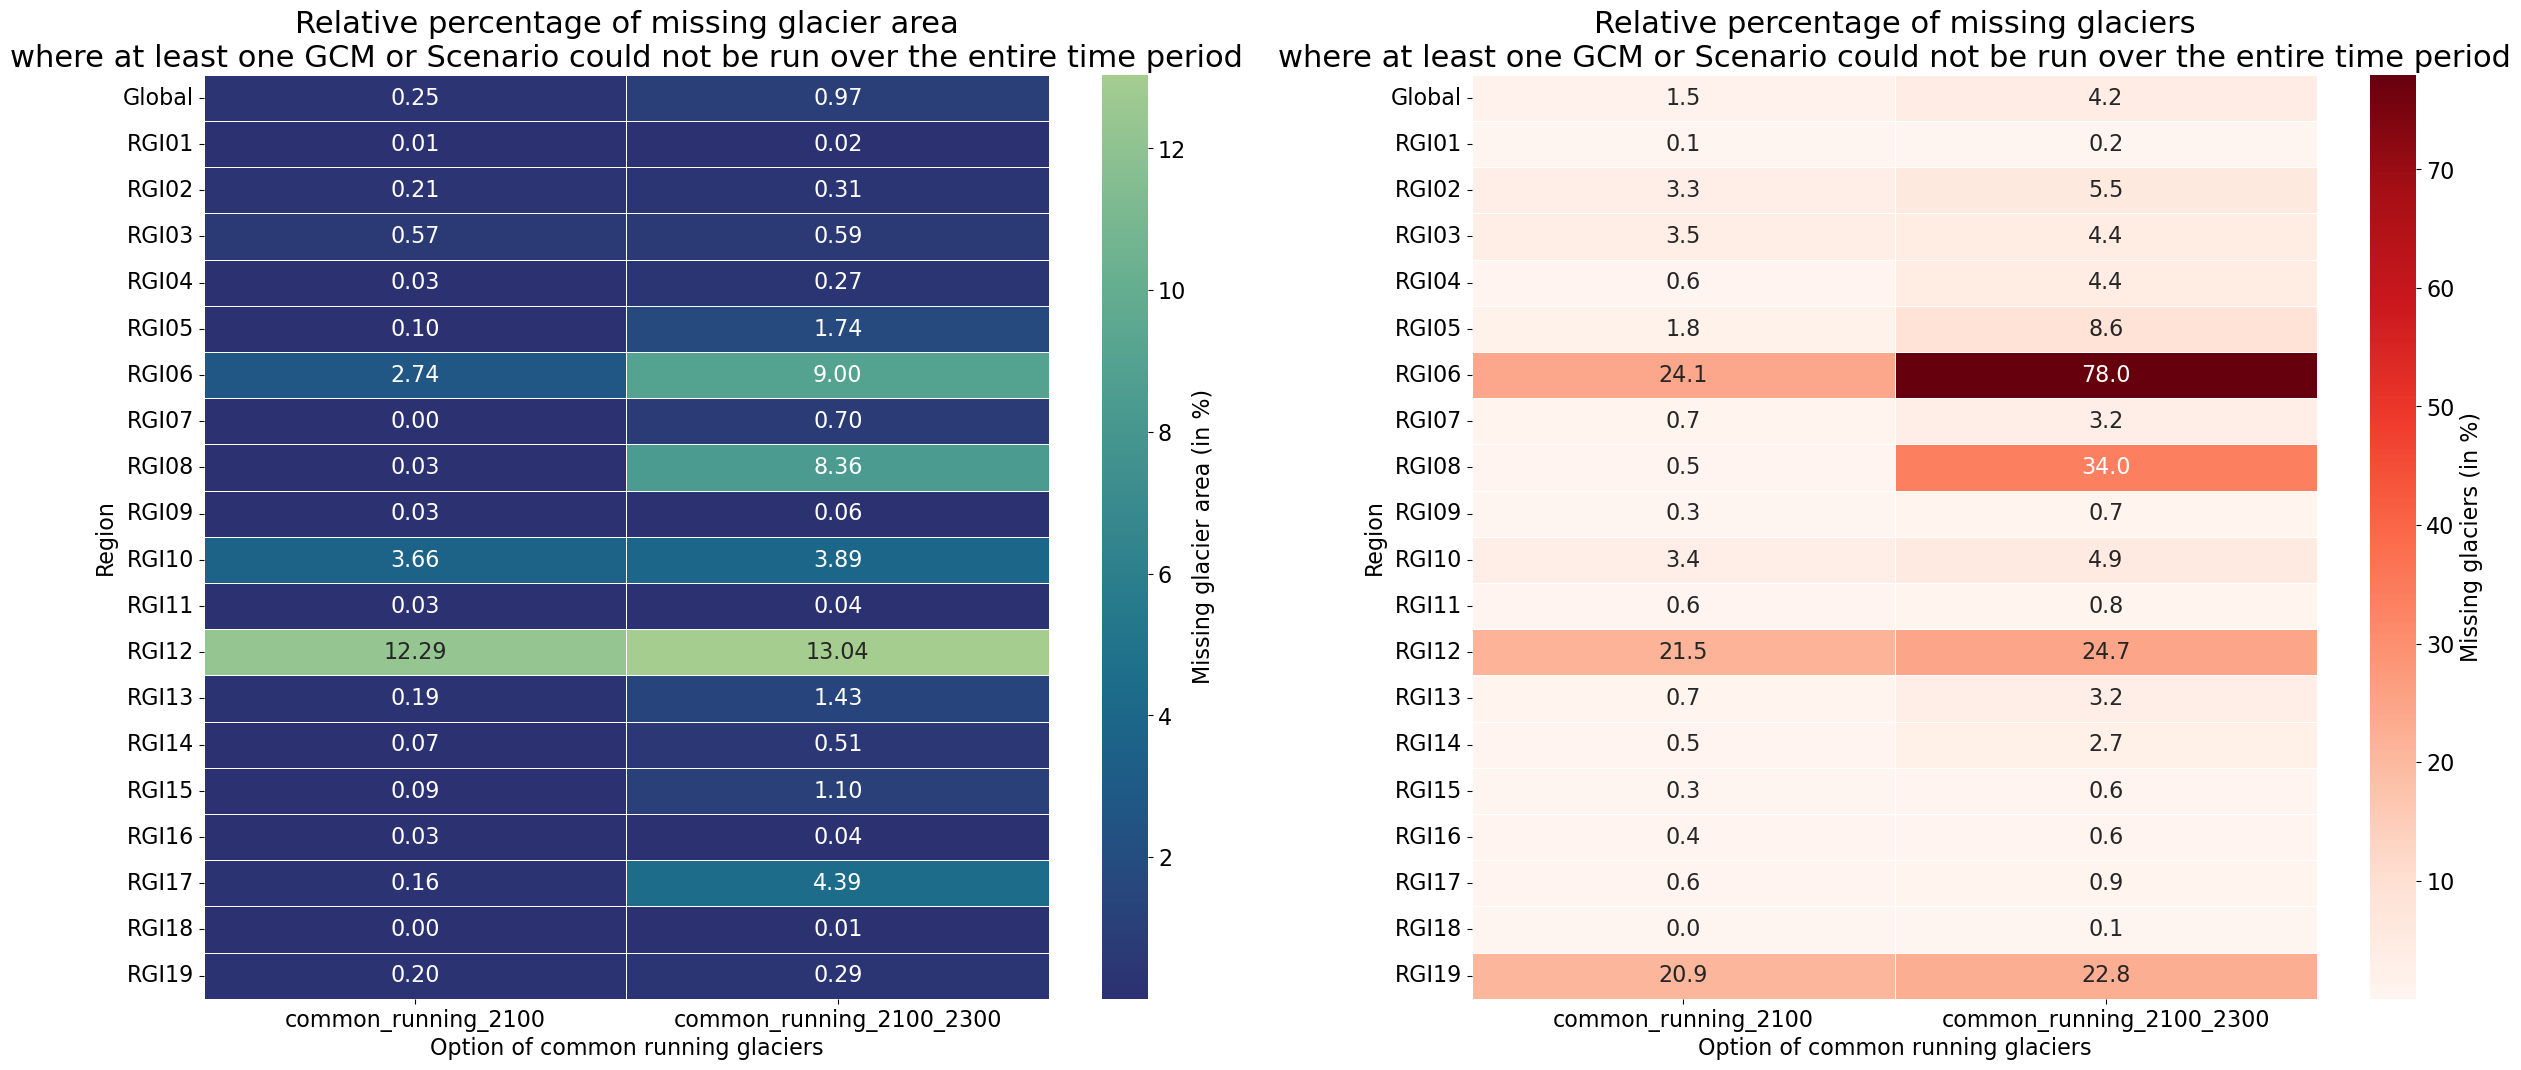

In [33]:
odf_2100= pd.read_csv(f'{outputpath}/common_running_2100/missing_region_overview.csv', index_col=0)
odf_2100.loc['Global'] = odf_2100.sum(axis=0)
# need to recompute the percentage
odf_2100['missing_area_perc'] = 100*odf_2100['missing_area_km2'] / odf_2100['rgi_area_km2']
odf_2100['missing_glaciers_perc'] = 100*odf_2100['n_missing_glaciers'] / odf_2100['n_glaciers']
odf_2100 = odf_2100.sort_index()

odf_2300= pd.read_csv(f'{outputpath}/common_running_2100_2300/missing_region_overview.csv', index_col=0)
odf_2300.loc['Global'] = odf_2300.sum(axis=0)
# need to recompute the percentage
odf_2300['missing_area_perc'] = 100*odf_2300['missing_area_km2'] / odf_2300['rgi_area_km2']
odf_2300['missing_glaciers_perc'] = 100*odf_2300['n_missing_glaciers'] / odf_2300['n_glaciers']
odf_2300 = odf_2300.sort_index()

import seaborn as sns

odf_area = odf_2100[['missing_area_perc']]
odf_area.index.name = 'Region'
odf_area.columns.name = 'Option of common running glaciers'
odf_area = odf_area.rename(columns={'missing_area_perc':'common_running_2100'})
odf_area['common_running_2100_2300'] = odf_2300['missing_area_perc']

odf_glac = odf_2100[['missing_glaciers_perc']]
odf_glac.index.name = 'Region'
odf_glac.columns.name = 'Option of common running glaciers'
odf_glac = odf_glac.rename(columns={'missing_glaciers_perc':'common_running_2100'})
odf_glac['common_running_2100_2300'] = odf_2300['missing_glaciers_perc']


plt.rc('font', size=16)
fig, axs = plt.subplots(1,2,figsize=(30,12))
ax = axs[0]
sns.heatmap(odf_area.astype(float), 
            ax=ax,
            annot=True, fmt=".2f",cmap="crest_r",linewidth=.5,
            cbar_kws={'label':'Missing glacier area (in %)'})
ax.set_title(f'Relative percentage of missing glacier area\nwhere at least one GCM or Scenario could not be run over the entire time period', fontsize=22)


ax = axs[1]
sns.heatmap(odf_glac.astype(float), annot=True, fmt=".1f",cmap="Reds",linewidth=.5, ax=ax,
            cbar_kws={'label':'Missing glaciers (in %)'})
ax.set_title(f'Relative percentage of missing glaciers\nwhere at least one GCM or Scenario could not be run over the entire time period', fontsize=22);
plt.savefig('missing_glacier_area_stats.png')
